In [ ]:
!git clone https://github.com/emillia-q/audio-violence-detection-tinyml.git
%cd audio-violence-detection-tinyml

from google.colab import drive
drive.mount('/content/drive')

!cp "/content/drive/MyDrive/audio-violence-detection-tflite/data.tar.gz" .
!tar -xzvf data.tar.gz

# Configuration and Imports
Importing necessary libraries.

In [3]:
# Config
import json
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
from typing import Tuple

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# Scripts
from scripts.splitting import get_source_name, grouped_balanced_split

# Metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Feature Extraction Function Definitions
Defining functions to extract MFCC features and crawl the directory structure.

In [4]:
def extract_features(file_path: str | Path, n_mfcc=13) -> np.ndarray:
    """
    Returns full MFCC Matrix (time x features).
    """
    y, sr = librosa.load(str(file_path), sr=16000)

    # SANITY: exactly 32000 samples (2 sec)
    # If y is to short - add zeroes, if too long - truncate
    y = librosa.util.fix_length(y, size=32000)

    # Calculate MFCC, 2s & sr=16000 with domain params gives around 63 frames
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

    # Preparation for CNN (time, features, channel)
    return mfcc.T[:,:,np.newaxis].astype(np.float32)

def load_dataset(processed_path: str | Path) -> Tuple[np.ndarray, np.ndarray, dict, list]:
    """
    Crawls the processed data directory to extract features from all samples
      while automatically generating a numeric label mapping based on folder names.
    """
    X, y, file_paths = [], [], []
    label_to_name = {}
    processed_dir = Path(processed_path)

    for category_dir in processed_dir.iterdir():
        if not category_dir.is_dir():
            continue

        try:
            label = int(category_dir.name.split('_')[0])
            clean_name = category_dir.name.split('_', 1)[1].replace('_', ' ').title()
            label_to_name[label] = clean_name
        except (ValueError, IndexError):
            continue

        for file_path in category_dir.glob("*.wav"):
            features = extract_features(file_path=file_path)
            X.append(features)
            y.append(label)
            file_paths.append(str(file_path))

    return np.array(X), np.array(y), label_to_name, file_paths

# Prepare Dataset

`load_dataset` runs MFCC extraction for every segment in `data/processed/`.

The split is **source-level and segment-balanced per class**: every original recording goes entirely to one of `train` / `val` / `test` (no leakage - `Leak check` must be all zeros) and each class is split into roughly **64% / 16% / 20%** of its **segments**, not just of its sources. This is necessary because source segment counts vary widely (one long ambient recording vs many short violence shouts), so plain source-level stratification leaves the per-class segment proportions in val/test very far from the train mix.

In [5]:
# Load data
DATA_PATH = Path('data/processed')
X, y, target_map, all_paths = load_dataset(DATA_PATH)
target_names = [target_map[i] for i in sorted(target_map.keys())]

meta = pd.DataFrame({
    "path": all_paths,
    "label": y,
    "source": [get_source_name(p) for p in all_paths]
})

train_sources, val_sources, test_sources = grouped_balanced_split(
    meta, val_size=0.16, test_size=0.20, random_state=42
)

# Filter data
train_mask = meta["source"].isin(train_sources).values
val_mask = meta["source"].isin(val_sources).values
test_mask = meta["source"].isin(test_sources).values

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"Train shape: {X_train.shape}") # Should be (N, 63, 13, 1)

Train shape: (16666, 63, 13, 1)


# CNN Model Architecture

In [9]:
def build_model(input_shape: Tuple[int, int, int], num_classes: int) -> tf.keras.Model:
    """
    Creates CNN architecture optimized for TinyML.
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # First splot layer (detects simple edges on sound)
        layers.Conv2D(16,(3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        # Second splot layer (more complex formulas)
        layers.Conv2D(32,(3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5), # Prevents overfitting
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_model(input_shape=X_train.shape[1:], num_classes=len(target_map))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 63, 13, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 6, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 31, 6, 32)      │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 3, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1440)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        92,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,219 (379.76 KB)

 Trainable params: 97,219 (379.76 KB)

 Non-trainable params: 0 (0.00 B)

# Training and Evaluation

Epoch 1/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.5950 - loss: 1.2113 - val_accuracy: 0.5674 - val_loss: 0.8119
Epoch 2/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6477 - loss: 0.8148 - val_accuracy: 0.7116 - val_loss: 0.7279
Epoch 3/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7174 - loss: 0.6675 - val_accuracy: 0.7543 - val_loss: 0.6363
Epoch 4/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8287 - loss: 0.4638 - val_accuracy: 0.7495 - val_loss: 0.6526
Epoch 5/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8741 - loss: 0.3494 - val_accuracy: 0.7838 - val_loss: 0.5882
Epoch 6/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8962 - loss: 0.2902 - val_accuracy: 0.7778 - val_loss: 0.6392
Epoch 7/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9054 - loss: 0.2651 - val_accuracy: 0.7490 - val_loss: 0.6975
Epoch 8/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9176 - loss: 0.2337 - val_accuracy: 0.

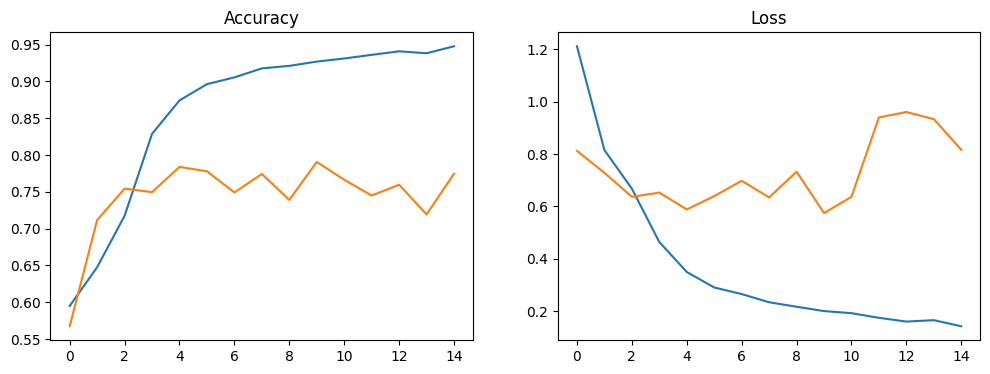

In [10]:
# Stops training when models has stopped correcting
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

# Charts
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1); plt.plot(history.history['accuracy'], label='train'); plt.plot(history.history['val_accuracy'], label='val'); plt.title('Accuracy')
plt.subplot(1, 2, 2); plt.plot(history.history['loss'], label='train'); plt.plot(history.history['val_loss'], label='val'); plt.title('Loss')
plt.show()